## Upgrade plot
One of the easiest things to mess up is the om mapping. This notebook is meant to plot the upgrade mapping defined in om.map and the geo file. Here I am using icecube_upgrade_new.geo.

Full map counts:
type
1    5160
3     357
4     266
Name: count, dtype: int64

Upgrade strings:
type     3   4
string        
87      51  38
88      51  38
89      51  38
90      51  38
91      51  38
92      51  38
93      51  38


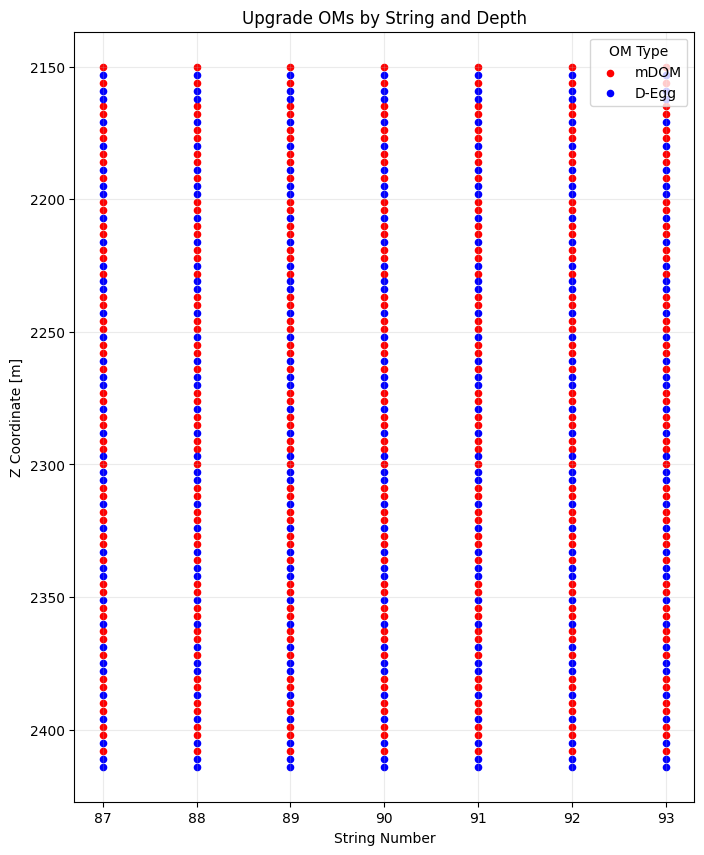

In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


EXAMPLE_DIR = Path.cwd()
REPO_DIR = EXAMPLE_DIR.parent

geo_file = REPO_DIR / "resources/geofiles/icecube_upgrade_new.geo"
map_file = REPO_DIR / "resources/PPC_tables/upgrade_tables/om.map"


# Geometry file has 4 header/metadata lines before the module data
geo = pd.read_csv(
    geo_file,
    sep=r"\s+",
    skiprows=4,
    names=["x", "y", "z", "string", "om"]
)

# OM map is simply: string, OM number, OM type
om_map = pd.read_csv(
    map_file,
    sep=r"\s+",
    names=["string", "om", "type"]
)

# Match OM types to their detector positions
modules = geo.merge(om_map, on=["string", "om"])

# Upgrade multi-PMT modules
mdom = modules[modules["type"] == 3]
degg = modules[modules["type"] == 4]

print("Full map counts:")
print(modules["type"].value_counts().sort_index())

print("\nUpgrade strings:")
print(
    modules[modules["string"].between(87, 93)]
    .groupby(["string", "type"])
    .size()
    .unstack(fill_value=0)
)
plt.figure(figsize=(8, 10))

plt.scatter(
    mdom["string"],
    -mdom["z"],
    s=20,
    color="red",
    label="mDOM"
)

plt.scatter(
    degg["string"],
    -degg["z"],
    s=20,
    color="blue",
    label="D-Egg"
)

plt.xlabel("String Number")
plt.ylabel("Z Coordinate [m]")
plt.title("Upgrade OMs by String and Depth")
plt.xticks(range(87, 94))
plt.gca().invert_yaxis()
plt.legend(title="OM Type")
plt.grid(alpha=0.25)

plt.show()

## Now all of IceCube with Upgrade:

In [18]:
from pathlib import Path

import pandas as pd

EXAMPLE_DIR = Path.cwd()
REPO_DIR = EXAMPLE_DIR.parent

geo_file = REPO_DIR / "resources/geofiles/icecube_upgrade_new.geo"
map_file = REPO_DIR / "resources/PPC_tables/upgrade_tables/om.map"

# Geometry file has 4 header lines
geo = pd.read_csv(
    geo_file,
    sep=r"\s+",
    skiprows=4,
    names=["x", "y", "z", "string", "om"]
)

om_map = pd.read_csv(
    map_file,
    sep=r"\s+",
    names=["string", "om", "type"]
)

modules = geo.merge(om_map, on=["string", "om"], how="left")

# Label sensor classes for plotting
def classify_sensor(row):
    s = row["string"]
    t = row["type"]
    
    if 87 <= s <= 93:
        if t == 3:
            return "mDOM"
        elif t == 4:
            return "D-Egg"
        else:
            return "Upgrade DOM/HQE"
    else:
        return "Main IceCube DOM/HQE"

modules["sensor_class"] = modules.apply(classify_sensor, axis=1)

modules["sensor_class"].value_counts()

sensor_class
Main IceCube DOM/HQE    5160
mDOM                     357
D-Egg                    266
Name: count, dtype: int64

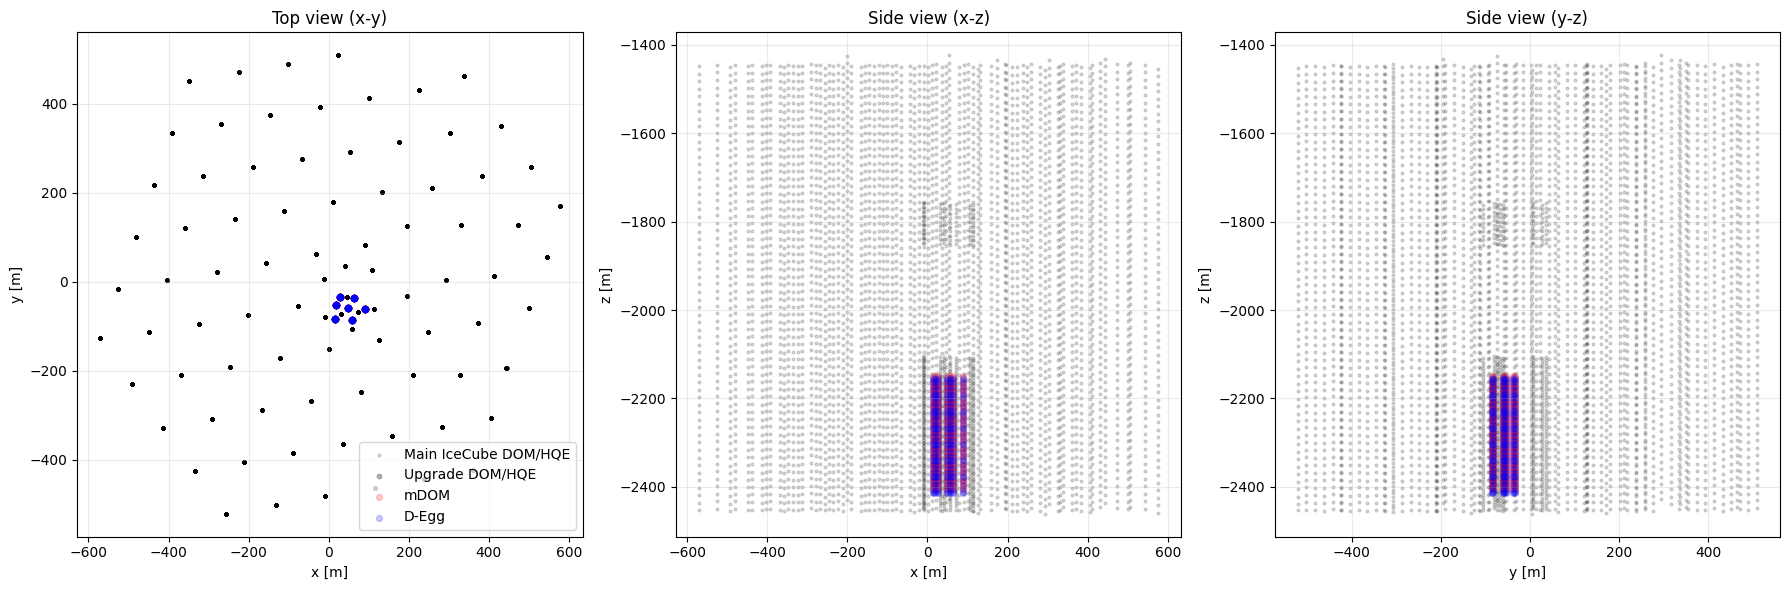

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# colors
colors = {
    "Main IceCube DOM/HQE": ("black", 0.15, 4),
    "Upgrade DOM/HQE": ("gray", 0.6, 10),
    "mDOM": ("red", 0.2, 18),
    "D-Egg": ("blue", 0.2, 18),
}

for label, (color, alpha, size) in colors.items():
    d = modules[modules["sensor_class"] == label]
    
    axes[0].scatter(d["x"], d["y"], s=size, c=color, alpha=alpha, label=label)
    axes[1].scatter(d["x"], d["z"], s=size, c=color, alpha=alpha, label=label)
    axes[2].scatter(d["y"], d["z"], s=size, c=color, alpha=alpha, label=label)

axes[0].set_title("Top view (x-y)")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")

axes[1].set_title("Side view (x-z)")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("z [m]")

axes[2].set_title("Side view (y-z)")
axes[2].set_xlabel("y [m]")
axes[2].set_ylabel("z [m]")

for ax in axes:
    ax.grid(alpha=0.25)

axes[0].legend(loc="best")
plt.tight_layout()
plt.show()

## interactive plot:

In [20]:
import plotly.graph_objects as go

main = modules[modules["sensor_class"] == "Main IceCube DOM/HQE"]
upgrade_dom = modules[modules["sensor_class"] == "Upgrade DOM/HQE"]
mdom = modules[modules["sensor_class"] == "mDOM"]
degg = modules[modules["sensor_class"] == "D-Egg"]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=main["x"],
    y=main["y"],
    z=main["z"],
    mode="markers",
    name="Main IceCube DOM/HQE",
    marker=dict(
        size=2,
        color="rgba(80,80,80,0.85)"
    ),
    hovertemplate="String %{text}<br>x=%{x:.1f}<br>y=%{y:.1f}<br>z=%{z:.1f}<extra></extra>",
    text=main["string"].astype(str) + "-" + main["om"].astype(str)
))

fig.add_trace(go.Scatter3d(
    x=upgrade_dom["x"],
    y=upgrade_dom["y"],
    z=upgrade_dom["z"],
    mode="markers",
    name="Upgrade DOM/HQE",
    marker=dict(
        size=3,
        color="rgba(0,0,0,0.5)"
    ),
    hovertemplate="Upgrade DOM %{text}<br>x=%{x:.1f}<br>y=%{y:.1f}<br>z=%{z:.1f}<extra></extra>",
    text=upgrade_dom["string"].astype(str) + "-" + upgrade_dom["om"].astype(str)
))

fig.add_trace(go.Scatter3d(
    x=mdom["x"],
    y=mdom["y"],
    z=mdom["z"],
    mode="markers",
    name="mDOM",
    marker=dict(
        size=4,
        color="red"
    ),
    hovertemplate="mDOM %{text}<br>x=%{x:.1f}<br>y=%{y:.1f}<br>z=%{z:.1f}<extra></extra>",
    text=mdom["string"].astype(str) + "-" + mdom["om"].astype(str)
))

fig.add_trace(go.Scatter3d(
    x=degg["x"],
    y=degg["y"],
    z=degg["z"],
    mode="markers",
    name="D-Egg",
    marker=dict(
        size=4,
        color="blue"
    ),
    hovertemplate="D-Egg %{text}<br>x=%{x:.1f}<br>y=%{y:.1f}<br>z=%{z:.1f}<extra></extra>",
    text=degg["string"].astype(str) + "-" + degg["om"].astype(str)
))

fig.update_layout(
    title="IceCube + Upgrade Geometry",
    scene=dict(
        xaxis_title="x [m]",
        yaxis_title="y [m]",
        zaxis_title="z [m]",
        aspectmode="data"
    ),
    width=950,
    height=800,
    legend=dict(x=0.02, y=0.98)
)

fig.show()